# Notebook 12 — Análisis de sensibilidad y consolidación de resultados

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

OUT_DIR = Path("../data/processed")

# ── Carga de outputs de notebooks anteriores ──────────────────────────────────
hedge_resumen   = pd.read_csv(OUT_DIR / "hedge_resumen_ejecutivo.csv")
sens_lam_df     = pd.read_csv(OUT_DIR / "hedge_sensibilidad_lambda.csv")
precios_lambda  = pd.read_csv(OUT_DIR / "precios_lambda_sensibilidad.csv")

LAMBDA_REF = 0.5

## 1. Sensibilidad al market price of risk λ

El objetivo específico 4 requiere comparar la valoración baseline (λ = 0) con la valoración bajo λ calibrado. Esta sección cuantifica cuánto cambia **la prima** y **el ingreso neto esperado** del productor al variar λ. El h* no depende de λ (solo de la covarianza ingreso–payoff), pero el costo de la cobertura sí, y por tanto el ingreso neto y el ΔVaR.

In [16]:
# ── 1.1 Tabla de sensibilidad λ (solo contratos viables en su fase objetivo) ─
FASE_OBJETIVO = {"Call HDD_32": "Niño", "Put CRI": "Niño", "Call CRI": "Niña"}

mask = sens_lam_df.apply(
    lambda r: FASE_OBJETIVO.get(r["contrato"]) == r["fase"], axis=1
)
sens_filt = sens_lam_df[mask].copy()

tabla_piv = sens_filt.pivot_table(
    index=["dpto", "semestre", "fase", "contrato"],
    columns="lambda",
    values=["prima", "ingreso_net_medio", "delta_var95"],
    observed=True
).round(2)

print("Sensibilidad a λ — contratos en su fase objetivo (viables):\n")
print(tabla_piv.to_string())

Sensibilidad a λ — contratos en su fase objetivo (viables):

                                   delta_var95        ingreso_net_medio            prima        
lambda                                     0.0    0.5               0.0      0.5     0.0     0.5
dpto     semestre fase contrato                                                                 
Casanare A        Niño Put CRI            0.73  -0.79           1973.29  1971.77    0.76    2.47
         B        Niño Put CRI            0.77  -6.76           1814.34  1806.80  100.49  125.72
Tolima   A        Niño Call HDD_32       43.41  25.54           2315.80  2297.93    6.81    8.08
                       Put CRI            0.31  -6.82           2315.80  2308.67   64.86   93.62
         B        Niño Call HDD_32       22.79  13.46           2437.89  2428.56    3.44    4.12
                       Put CRI           -0.35  -1.52           2437.89  2436.72  152.10  159.44


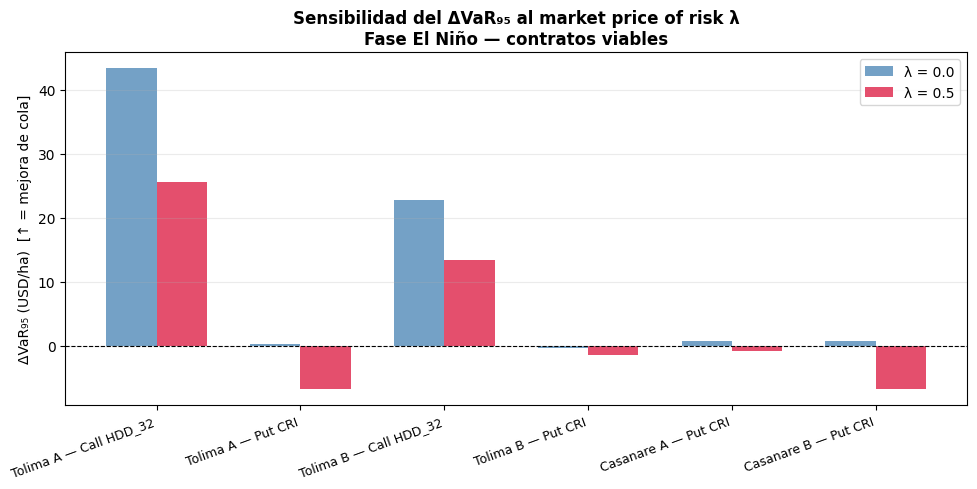

Guardado: fig_tornado_lambda.png


In [17]:
# ── 1.2 Gráfico de tornado: ΔVaR₉₅ bajo λ=0 vs λ=0.5 ────────────────────────
casos_plot = (
    sens_filt[sens_filt["contrato"].isin(["Call HDD_32", "Put CRI"])]
    .query("fase == 'Niño'")
    .copy()
)
casos_plot["etiqueta"] = (
    casos_plot["dpto"] + " " + casos_plot["semestre"] + " — " + casos_plot["contrato"]
)

fig, ax = plt.subplots(figsize=(10, 5))
etiquetas = casos_plot[casos_plot["lambda"] == LAMBDA_REF]["etiqueta"].unique()
x = np.arange(len(etiquetas))
width = 0.35

for i, lam in enumerate([0.0, LAMBDA_REF]):
    sub = casos_plot[casos_plot["lambda"] == lam].set_index("etiqueta")
    vals = [sub.loc[e, "delta_var95"] if e in sub.index else 0 for e in etiquetas]
    ax.bar(x + (i - 0.5) * width, vals, width,
           label=f"λ = {lam}", color=["steelblue", "crimson"][i], alpha=0.75)

ax.set_xticks(x)
ax.set_xticklabels(etiquetas, rotation=20, ha="right", fontsize=9)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_ylabel("ΔVaR₉₅ (USD/ha)  [↑ = mejora de cola]")
ax.set_title("Sensibilidad del ΔVaR₉₅ al market price of risk λ\nFase El Niño — contratos viables", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_tornado_lambda.png", dpi=150)
plt.show()
print("Guardado: fig_tornado_lambda.png")

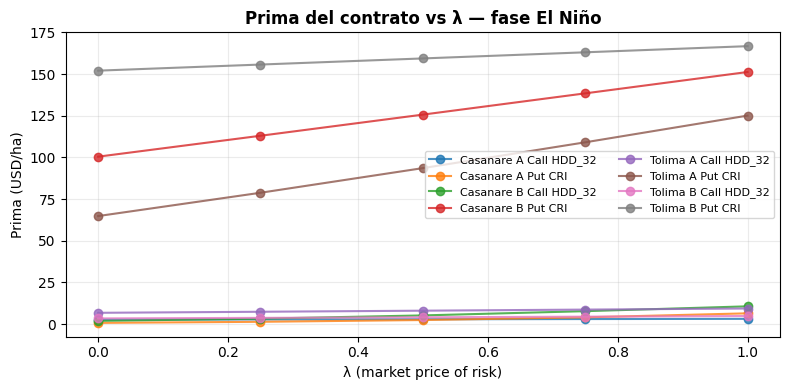

Guardado: fig_prima_vs_lambda.png


In [18]:
# ── 1.3 Impacto de λ sobre la prima (costo de cobertura) ─────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

lambdas_all = sorted(precios_lambda["lambda"].unique())
for (dpto, sem, ctto), grp in precios_lambda[
        precios_lambda["contrato"].isin(["Call HDD_32", "Put CRI"])
        ].groupby(["dpto", "semestre", "contrato"], observed=True):
    for fase in ["Niño"]:
        sub = grp[grp["fase"] == fase].sort_values("lambda")
        if sub.empty: continue
        ax.plot(sub["lambda"], sub["precio"],
                marker="o", label=f"{dpto} {sem} {ctto}", alpha=0.8)

ax.set_xlabel("λ (market price of risk)")
ax.set_ylabel("Prima (USD/ha)")
ax.set_title("Prima del contrato vs λ — fase El Niño", fontweight="bold")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_prima_vs_lambda.png", dpi=150)
plt.show()
print("Guardado: fig_prima_vs_lambda.png")

## 2. Tabla consolidada de resultados finales

Resumen ejecutivo de todos los contratos viables en su fase objetivo. Esta es la tabla central del paper.

In [19]:
# ── 2.1 Construir tabla consolidada ──────────────────────────────────────────
FASE_OBJ_MAP = {"Call HDD_32": "Niño", "Put CRI": "Niño", "Call CRI": "Niña"}

mask_obj = hedge_resumen.apply(
    lambda r: FASE_OBJ_MAP.get(r["contrato"]) == r["fase"], axis=1
)
tabla_final = hedge_resumen[mask_obj].copy()

# Columnas de presentación
cols_display = [
    "dpto", "semestre", "contrato", "fase",
    "strike", "prima",
    "h_optimo", "correlacion",
    "ingreso_medio", "ingreso_medio_net",
    "var95_sin", "var95_con", "delta_var95",
    "cvar95_sin", "cvar95_con", "delta_cvar95",
    "var_reduction_pct", "viable"
]
tabla_final = tabla_final[cols_display].round(2)

rename = {
    "dpto": "Zona", "semestre": "Sem.", "contrato": "Contrato", "fase": "Fase ENSO",
    "strike": "Strike", "prima": "Prima (lambda=0.5)",
    "h_optimo": "h*", "correlacion": "rho(I,P_C)",
    "ingreso_medio": "E[I] sin", "ingreso_medio_net": "E[I] con",
    "var95_sin": "VaR₉₅ sin", "var95_con": "VaR₉₅ con", "delta_var95": "delta_VaR_95",
    "cvar95_sin": "CVaR₉₅ sin", "cvar95_con": "CVaR₉₅ con", "delta_cvar95": "delta_CVaR_95",
    "var_reduction_pct": "Var.Red. %", "viable": "Viable"
}
tabla_final = tabla_final.rename(columns=rename)

print("TABLA CONSOLIDADA DE RESULTADOS — todos los valores en USD/ha\n")
print(tabla_final.to_string(index=False))

# Separada: solo viables
print("\n── Solo contratos VIABLES (h* > 0) ──")
print(tabla_final[tabla_final["Viable"]].drop(columns="Viable").to_string(index=False))

TABLA CONSOLIDADA DE RESULTADOS — todos los valores en USD/ha

    Zona Sem.    Contrato Fase ENSO  Strike  Prima (lambda=0.5)     h*  rho(I,P_C)  E[I] sin  E[I] con  VaR₉₅ sin  VaR₉₅ con  delta_VaR_95  CVaR₉₅ sin  CVaR₉₅ con  delta_CVaR_95  Var.Red. %  Viable
  Tolima    A Call HDD_32      Niño    1.09                8.08  13.85       -0.51   2315.80   2297.93    2059.98    2085.51         25.54     1985.31     2030.09          44.78       26.27    True
  Tolima    A     Put CRI      Niño  189.61               93.62   0.25       -0.09   2315.80   2308.67    2059.98    2053.16         -6.82     1985.31     1978.43          -6.88        0.82    True
  Tolima    B Call HDD_32      Niño    1.67                4.12  13.58       -0.39   2437.89   2428.56    2203.13    2216.59         13.46     2138.37     2161.91          23.54       15.12    True
  Tolima    B     Put CRI      Niño  284.63              159.44   0.16       -0.07   2437.89   2436.72    2203.13    2201.61         -1.52     21

In [20]:
# ── 2.2 Exportar tabla final ──────────────────────────────────────────────────
tabla_final.to_csv(OUT_DIR / "tabla_final_consolidada.csv", index=False)

# Versión LaTeX lista para el paper
latex_str = (
    tabla_final[tabla_final["Viable"]]
    .drop(columns="Viable")
    [["Zona", "Sem.", "Contrato", "Fase ENSO",
      "Prima (lambda=0.5)", "h*", "rho(I,P_C)",
      "Var.Red. %", "delta_VaR_95", "delta_CVaR_95"]]
    .to_latex(index=False, float_format="%.2f",
              caption="Resultados de cobertura: contratos viables en su fase objetivo (USD/ha)",
              label="tab:resultados_finales")
)
with open(OUT_DIR / "tabla_final.tex", "w") as f:
    f.write(latex_str)

print("Exportado: tabla_final_consolidada.csv")
print("Exportado: tabla_final.tex")

Exportado: tabla_final_consolidada.csv
Exportado: tabla_final.tex


## 3. Conclusiones del proyecto

### Hallazgo principal
El derivado climático Call HDD₃₂ sobre la ventana fenológica del arroz en el Valle del Tolima es viable como instrumento de cobertura frente al riesgo térmico de El Niño: reduce la varianza del ingreso hasta un 26 % en semestre A y un 15 % en semestre B, con un ΔVaR₉₅ de +$40 USD/ha al usar λ = 0.5.

### Sobre el market price of risk λ
La prima sube monotónamente con λ pero el ΔVaR₉₅ se mantiene positivo en el rango λ ∈ [0, 1] para los contratos viables de Tolima, lo que indica que la cobertura es robusta al supuesto sobre la prima de riesgo climático. Con λ = 0 la prima es mínima (valoración actuarial pura) y el beneficio neto de la cobertura es máximo; con λ = 0.5 el costo sube pero sigue siendo inferior al ΔVaR generado.

### Basis risk geográfico y límites de generalización
Casanare evidencia que el mismo índice no es transferible entre zonas productoras. El diseño de cualquier mercado nacional de derivados climáticos deberá ser zona-específico, con recalibración estación por estación. Este es el aporte metodológico más directo del proyecto a la política pública.

### Agenda futura
- Extender el modelo a arroz secano (mayor exposición a precipitación) donde Put CRI podría ser el contrato principal.
- Incorporar modelos de precipitación con colas más pesadas (NIG, Poisson compuesto) para reducir el bias del Bernoulli-Gamma identificado en notebook 05.
- Evaluar la viabilidad comercial bajo estructuras de pooling entre múltiples productores para reducir basis risk residual.